20260425000000-240h-enfo-tf.bufr:   0%|          | 0.00/325k [00:00<?, ?B/s]

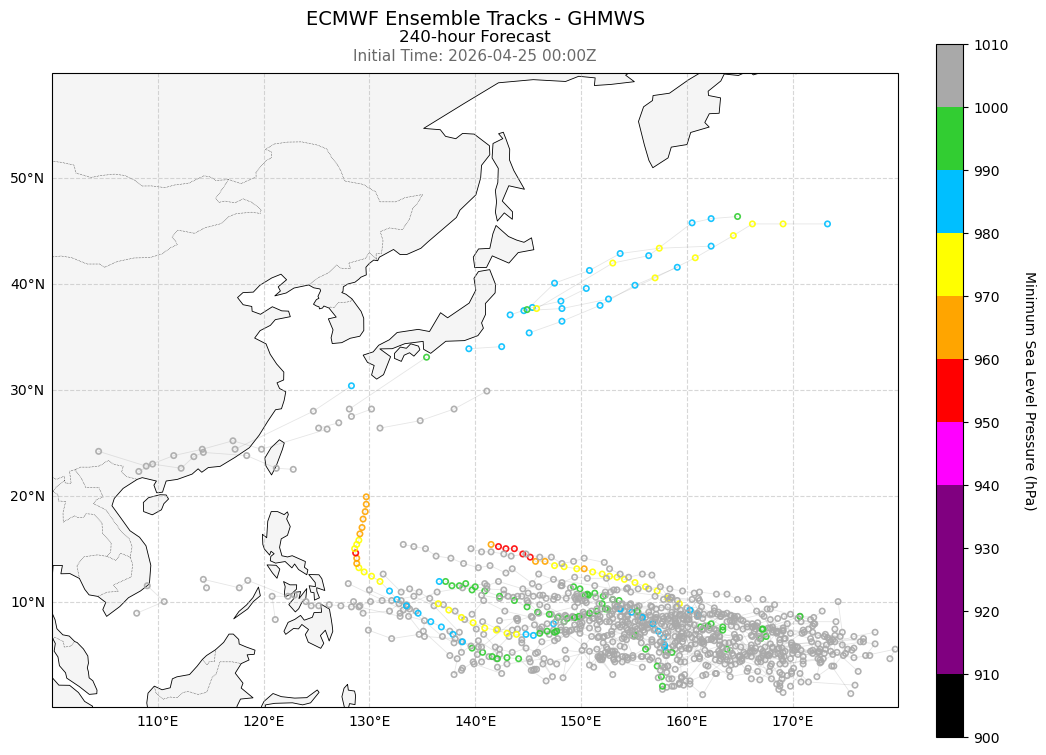

In [6]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from ecmwf.opendata import Client
import earthkit.data

path = r"C:\Users\andyzhang\Desktop\moweather\Tropical Cyclone 2026\集合預報"
if not os.path.exists(path):
    os.makedirs(path)

target_bufr = os.path.join(path, "ifs-2026-04-25-00Z.bufr")
csv_nwp = os.path.join(path, "ifs-2026-04-25-00Z-NWP.csv")

client = Client(source="ecmwf")
client.retrieve(
    date="2026-04-25", time=0, model="ifs", type="tf", 
    stream="enfo", step=240, target=target_bufr
)

ds = earthkit.data.from_source("file", target_bufr)
df = ds.to_pandas(
    columns=["stormIdentifier", "ensembleMemberNumber", "typicalDate", "typicalTime", 
             "year", "month", "day", "hour", "latitude", "longitude", "pressureReducedToMeanSeaLevel"],
    filters={"meteorologicalAttributeSignificance": 1},
    required_columns=True
)

df = df.dropna(subset=['year', 'month', 'day', 'hour', 'longitude', 'latitude']).copy()

b_date = df['typicalDate'].astype(int).astype(str)
b_time = df['typicalTime'].astype(int).astype(str).str.zfill(4) 
df['base_dt'] = pd.to_datetime(b_date + b_time, format='%Y%m%d%H%M')
df['valid_dt'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])
df['hours'] = (df['valid_dt'] - df['base_dt']).dt.total_seconds() / 3600
df['pressure'] = df['pressureReducedToMeanSeaLevel'] / 100.0

df = df.rename(columns={"stormIdentifier": "track", "ensembleMemberNumber": "sample", 
                        "longitude": "lon", "latitude": "lat"})

df_nwp = df[df['track'].astype(str).str.endswith('W', na=False)].copy()
df_nwp.to_csv(csv_nwp, index=False, encoding='utf-8-sig')

base_time_str = df_nwp['base_dt'].iloc[0].strftime('%Y-%m-%d %H:%MZ')

bounds = [900, 910, 920, 930, 940, 950, 960, 970, 980, 990, 1000, 1010]
colors = [
    '#000000', # 900-910: 黑
    '#800080', # 910-920: 深紫
    '#800080', # 920-930: 深紫
    '#800080', # 930-940: 深紫
    '#FF00FF', # 940-950: 洋紅
    '#FF0000', # 950-960: 紅
    '#FFA500', # 960-970: 橙
    '#FFFF00', # 970-980: 黃
    '#00BFFF', # 980-990: 藍
    '#32CD32', # 990-1000: 綠
    '#A9A9A9'  # 1000-1010: 灰
]

cmap = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm(bounds, cmap.N)

fig = plt.figure(figsize=(12, 9), dpi=100)
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([100, 180, 0, 60], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.COASTLINE, linewidth=0.6, zorder=2)
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.4, zorder=2)
ax.add_feature(cfeature.LAND, facecolor='#f5f5f5', zorder=1)

gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
gl.top_labels = False
gl.right_labels = False

for _, group in df_nwp.groupby(['track', 'sample']):
    ax.plot(group['lon'], group['lat'], color='gray', linewidth=0.6, alpha=0.2, 
            transform=ccrs.PlateCarree(), zorder=3)

sc = ax.scatter(df_nwp['lon'], df_nwp['lat'], 
                edgecolors=cmap(norm(df_nwp['pressure'])), 
                facecolors='none', 
                s=15,             
                linewidths=1.2,    
                alpha=0.9, 
                transform=ccrs.PlateCarree(), zorder=4)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = plt.colorbar(sm, ax=ax, pad=0.04, fraction=0.05, aspect=25)
cbar.set_label('Minimum Sea Level Pressure (hPa)', rotation=270, labelpad=20)
cbar.set_ticks(bounds) 

plt.title("ECMWF Ensemble Tracks - GHMWS", fontsize=14, pad=35)
plt.text(0.5, 1.05, "240-hour Forecast", 
         transform=ax.transAxes, ha='center', fontsize=12, color='black')
plt.text(0.5, 1.02, f"Initial Time: {base_time_str}", 
         transform=ax.transAxes, ha='center', fontsize=11, color='dimgray')

plt.show()